<a href="https://colab.research.google.com/github/Aryaa245/Analisis-Sentimen-Pengguna-Aplikasi-TikTok-pada-Google-Play-Store-Menggunakan-Algoritma-Naive-Bayes/blob/main/UAS_Bataona_23_11_5477.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up Dataset Melalui API Kaggle

In [1]:
!pip install kaggle


In [2]:
from google.colab import files
files.upload()   # upload kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aryabayu","key":"ac5e5daf717c459cadea1c18c800c128"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
!kaggle datasets download -d pandaa12/tiktok-app-reviews-indonesia-google-play-store


Dataset URL: https://www.kaggle.com/datasets/pandaa12/tiktok-app-reviews-indonesia-google-play-store
License(s): apache-2.0
  0% 0.00/3.10M [00:00<?, ?B/s]
100% 3.10M/3.10M [00:00<00:00, 1.09GB/s]


In [5]:
!unzip tiktok-app-reviews-indonesia-google-play-store.zip


Archive:  tiktok-app-reviews-indonesia-google-play-store.zip
  inflating: ulasan_com.ss.android.ugc.trill.csv  


# LOAD DATASET

In [6]:
import pandas as pd

df = pd.read_csv('ulasan_com.ss.android.ugc.trill.csv')
# df = df.sample(n=3000, random_state=42).reset_index(drop=True)

df.head()


,Nama User,Ulasan,Rating,Tanggal,Likes,Versi App
0,Pengguna Google,aplikasi nya seru banget minn aku suka sering ...,5,2025-12-31 17:31:32,0,43.1.4
1,Pengguna Google,susah mulung skrg,5,2025-12-31 17:28:37,0,43.1.4
2,Pengguna Google,tik tok rusak yg pada ngomong kasar di laporka...,1,2025-12-31 17:25:28,0,40.1.4
3,Pengguna Google,seru,4,2025-12-31 17:23:56,0,NaN
4,Pengguna Google,tiktok ny ga bisa di cptin suka nykrol sendiri...,1,2025-12-31 17:21:25,0,43.1.4


# Data Understanding

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Nama User  100000 non-null  object
 1   Ulasan     100000 non-null  object
 2   Rating     100000 non-null  int64 
 3   Tanggal    100000 non-null  object
 4   Likes      100000 non-null  int64 
 5   Versi App  61359 non-null   object
dtypes: int64(2), object(4)
memory usage: 4.6+ MB


# Preprocessing Data

In [8]:
df = df[['Ulasan', 'Rating']]
df.dropna(inplace=True)

# hapus ulasan kosong
df = df[df['Ulasan'].str.strip() != ""]


In [9]:
# buang netral
df = df[df['Rating'] != 3]

df['sentiment'] = df['Rating'].apply(
    lambda x: 'positive' if x >= 4 else 'negative'
)

df['sentiment'].value_counts()


,count
sentiment,
positive,56938
negative,35802


/tmp/ipython-input-2257103666.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


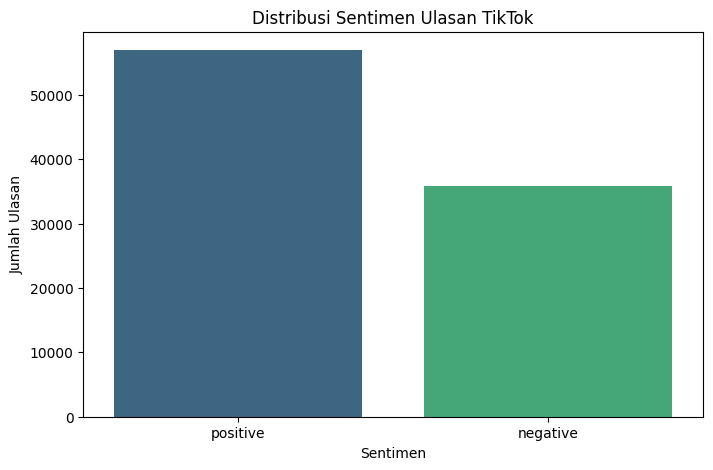

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribusi Sentimen Ulasan TikTok')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_ulasan'] = df['Ulasan'].apply(clean_text)


In [12]:
df

,Ulasan,Rating,sentiment,clean_ulasan
0,aplikasi nya seru banget minn aku suka sering ...,5,positive,aplikasi nya seru banget minn aku suka sering ...
1,susah mulung skrg,5,positive,susah mulung skrg
2,tik tok rusak yg pada ngomong kasar di laporka...,1,negative,tik tok rusak yg pada ngomong kasar di laporka...
3,seru,4,positive,seru
4,tiktok ny ga bisa di cptin suka nykrol sendiri...,1,negative,tiktok ny ga bisa di cptin suka nykrol sendiri...
...,...,...,...,...
99995,"aplikasi yang bagus,banyak hiburan,ilmu yang b...",5,positive,aplikasi yang bagusbanyak hiburanilmu yang bis...
99996,kok posting ulng saya ga adaa yaa min...,1,negative,kok posting ulng saya ga adaa yaa min
99997,apk ini sangat apik rekkkkk,5,positive,apk ini sangat apik rekkkkk
99998,sangat bgus,5,positive,sangat bgus


# TF IDF

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000
)

X = tfidf.fit_transform(df['clean_ulasan'])
y = df['sentiment']


# Spliting Data

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Modeling : Naive Bayes

In [15]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)


MultinomialNB()

# Matrix Evaluation

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8410610308389045
              precision    recall  f1-score   support

    negative       0.76      0.85      0.81      7160
    positive       0.90      0.84      0.87     11388

    accuracy                           0.84     18548
   macro avg       0.83      0.84      0.84     18548
weighted avg       0.85      0.84      0.84     18548



# Visualisasi

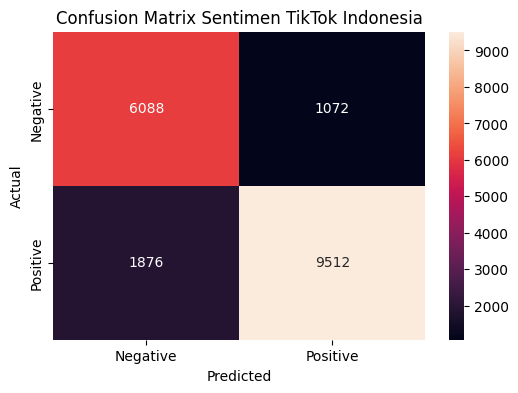

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Sentimen TikTok Indonesia")
plt.show()


In [18]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# World Cloud

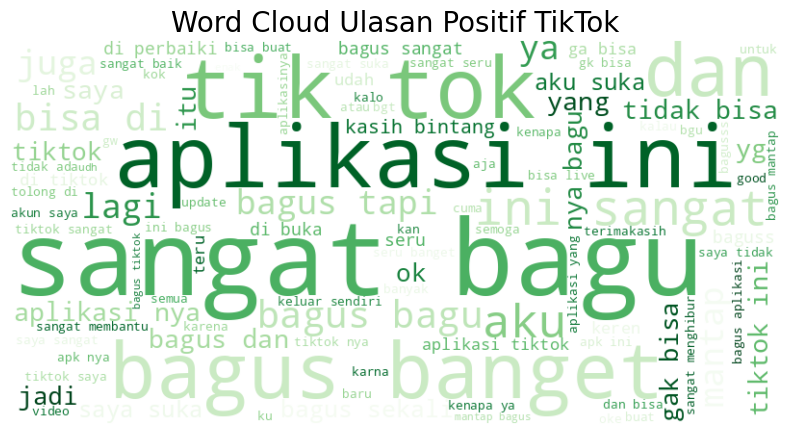

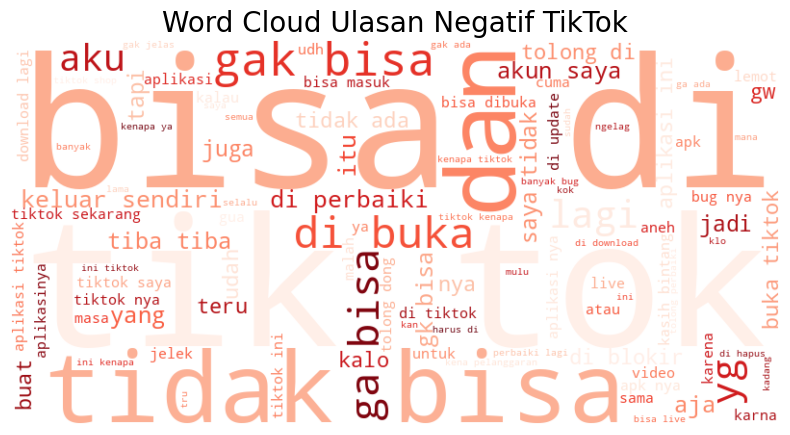

In [19]:
# Pisahkan ulasan berdasarkan label
positif_text = " ".join(df[df['sentiment'] == 'positive']['clean_ulasan'].astype(str))
negatif_text = " ".join(df[df['sentiment'] == 'negative']['clean_ulasan'].astype(str))

# Fungsi untuk menampilkan Word Cloud
def generate_wordcloud(text, title, color):
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap=color,
                          max_words=100).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()

# Tampilkan Word Cloud Positif
generate_wordcloud(positif_text, "Word Cloud Ulasan Positif TikTok", "Greens")

# Tampilkan Word Cloud Negatif
generate_wordcloud(negatif_text, "Word Cloud Ulasan Negatif TikTok", "Reds")

In [20]:
import joblib

# Simpan model
joblib.dump(model, 'model_naive_bayes_tiktok.pkl')
# Simpan vectorizer (penting agar bisa digunakan kembali)
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model dan Vectorizer berhasil disimpan!")

Model dan Vectorizer berhasil disimpan!
